# Training History Visualization

This notebook visualizes the training curves for all 5 models:
- **Two-Phase Models**: Standard Enhancer, Atrous Enhancer
- **Single-Phase Models**: UNet, ASPP-UNet, CLAHE-UNet

The visualizations show:
1. Phase 1 (Enhancers): UNet frozen during enhancer training
2. Phase 2 (Joint): Joint training of enhancer and UNet
3. Single-Phase: Direct UNet training

In [36]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

## Load Training History Data

In [37]:
# Define paths to training history files
results_dir = Path('../results')

# Two-phase models
enhancer_phase1_path = results_dir / 'enhancer_phase1_history.json'
enhancer_phase2_path = results_dir / 'enhancer_phase2_history.json'
atrous_enhancer_phase1_path = results_dir / 'atrous_enhancer_phase1_history.json'
atrous_enhancer_phase2_path = results_dir / 'atrous_enhancer_phase2_history.json'

# Single-phase models
unet_path = results_dir / 'training_history.json'
aspp_unet_path = results_dir / 'aspp_unet_training_history.json'
clahe_unet_path = results_dir / 'training_history_clahe.json'

# Load all training histories
def load_history(path):
    with open(path, 'r') as f:
        return json.load(f)

enhancer_p1 = load_history(enhancer_phase1_path)
enhancer_p2 = load_history(enhancer_phase2_path)
atrous_enhancer_p1 = load_history(atrous_enhancer_phase1_path)
atrous_enhancer_p2 = load_history(atrous_enhancer_phase2_path)
unet = load_history(unet_path)
aspp_unet = load_history(aspp_unet_path)
clahe_unet = load_history(clahe_unet_path)

print(f"Standard Enhancer Phase 1: {len(enhancer_p1['train_loss'])} epochs")
print(f"Standard Enhancer Phase 2: {len(enhancer_p2['train_loss'])} epochs")
print(f"Atrous Enhancer Phase 1: {len(atrous_enhancer_p1['train_loss'])} epochs")
print(f"Atrous Enhancer Phase 2: {len(atrous_enhancer_p2['train_loss'])} epochs")
print(f"UNet: {len(unet['train_loss'])} epochs")
print(f"ASPP-UNet: {len(aspp_unet['train_loss'])} epochs")
print(f"CLAHE-UNet: {len(clahe_unet['train_loss'])} epochs")

Standard Enhancer Phase 1: 26 epochs
Standard Enhancer Phase 2: 20 epochs
Atrous Enhancer Phase 1: 50 epochs
Atrous Enhancer Phase 2: 25 epochs
UNet: 100 epochs
ASPP-UNet: 67 epochs
CLAHE-UNet: 100 epochs


## Visualization 1: Phase 1 (Enhancers) - UNet Frozen

During Phase 1, the UNet is frozen and only the enhancer is trained.

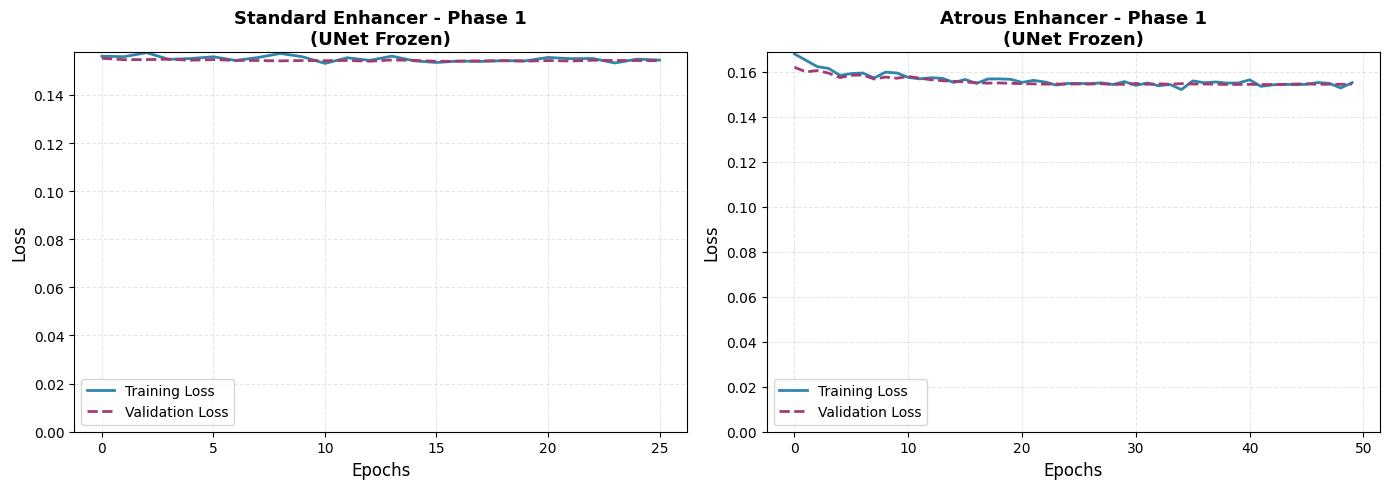

Standard Enhancer Phase 1 - Final Train Loss: 0.154448
Atrous Enhancer Phase 1 - Final Train Loss: 0.155013


In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Standard Enhancer Phase 1
ax1.plot(enhancer_p1['train_loss'], linewidth=2, color='#2E86AB', label='Training Loss')
if 'val_loss' in enhancer_p1:
    ax1.plot(enhancer_p1['val_loss'], linewidth=2, linestyle='--', 
             color='#A23B72', label='Validation Loss')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Standard Enhancer - Phase 1\n(UNet Frozen)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=10)
ax1.set_ylim(bottom=0)

# Atrous Enhancer Phase 1
ax2.plot(atrous_enhancer_p1['train_loss'], linewidth=2, color='#2E86AB', label='Training Loss')
if 'val_loss' in atrous_enhancer_p1:
    ax2.plot(atrous_enhancer_p1['val_loss'], linewidth=2, linestyle='--', 
             color='#A23B72', label='Validation Loss')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Atrous Enhancer - Phase 1\n(UNet Frozen)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=10)
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../results/phase1_enhancers_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Standard Enhancer Phase 1 - Final Train Loss: {enhancer_p1['train_loss'][-1]:.6f}")
print(f"Atrous Enhancer Phase 1 - Final Train Loss: {atrous_enhancer_p1['train_loss'][-1]:.6f}")

## Visualization 2: Phase 2 (Joint) - Joint Training

During Phase 2, both the enhancer and UNet are trained together.

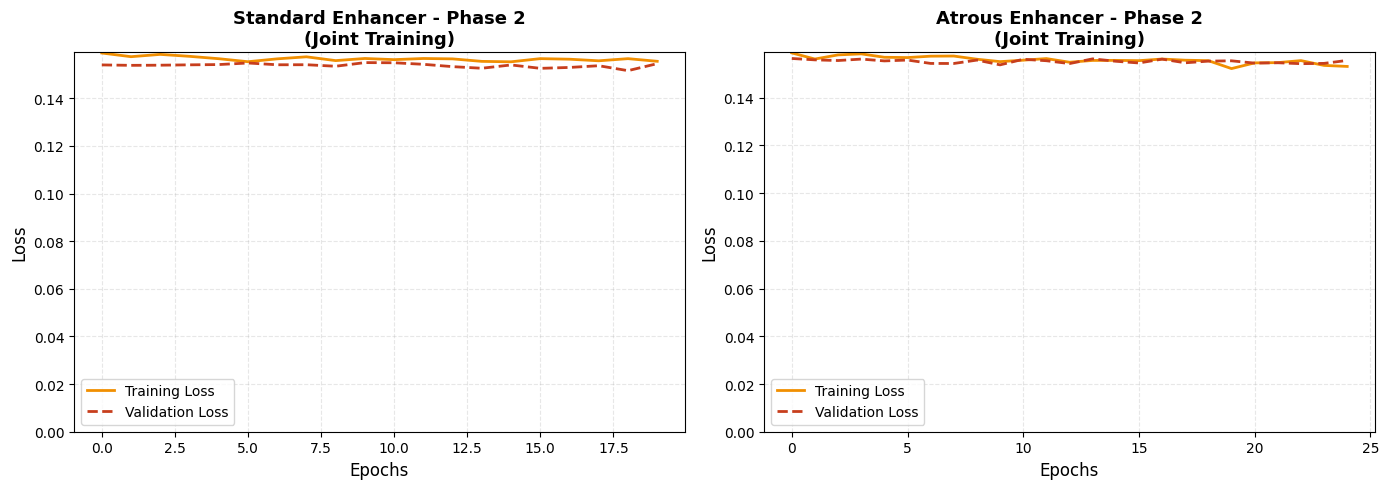

Standard Enhancer Phase 2 - Final Train Loss: 0.155521
Atrous Enhancer Phase 2 - Final Train Loss: 0.153091


In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Standard Enhancer Phase 2
ax1.plot(enhancer_p2['train_loss'], linewidth=2, color='#F18F01', label='Training Loss')
if 'val_loss' in enhancer_p2:
    ax1.plot(enhancer_p2['val_loss'], linewidth=2, linestyle='--', 
             color='#C73E1D', label='Validation Loss')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Standard Enhancer - Phase 2\n(Joint Training)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=10)
ax1.set_ylim(bottom=0)

# Atrous Enhancer Phase 2
ax2.plot(atrous_enhancer_p2['train_loss'], linewidth=2, color='#F18F01', label='Training Loss')
if 'val_loss' in atrous_enhancer_p2:
    ax2.plot(atrous_enhancer_p2['val_loss'], linewidth=2, linestyle='--', 
             color='#C73E1D', label='Validation Loss')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Atrous Enhancer - Phase 2\n(Joint Training)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=10)
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../results/phase2_joint_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Standard Enhancer Phase 2 - Final Train Loss: {enhancer_p2['train_loss'][-1]:.6f}")
print(f"Atrous Enhancer Phase 2 - Final Train Loss: {atrous_enhancer_p2['train_loss'][-1]:.6f}")

## Visualization 3: Single-Phase Models (UNet Variants)

These models train the UNet directly without an enhancer component.

In [40]:
# Plot formatting constants for IEEE paper compliance
AXIS_LABEL_FONT_SIZE = 18
TITLE_FONT_SIZE = 20
TICK_LABEL_FONT_SIZE = 20
LEGEND_FONT_SIZE = 18
LINE_WIDTH = 3
DPI = 300

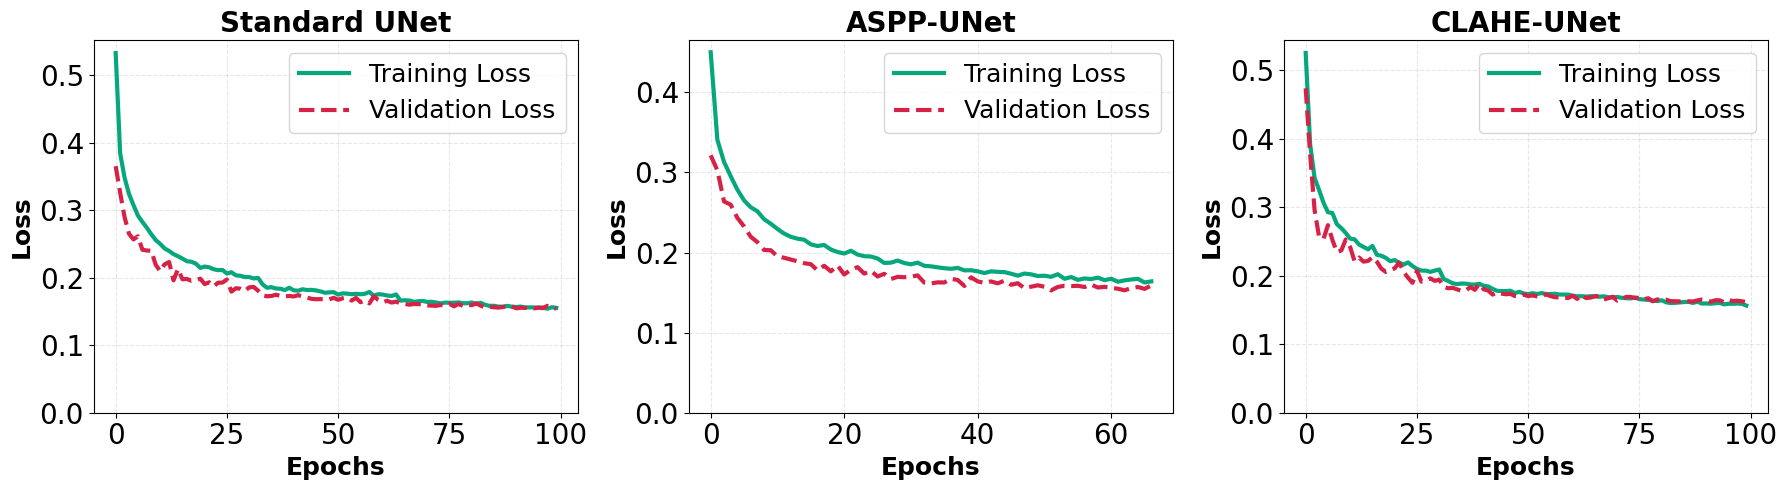

Standard UNet - Final Train Loss: 0.155209
ASPP-UNet - Final Train Loss: 0.164017
CLAHE-UNet - Final Train Loss: 0.156431


In [41]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Standard UNet
ax1.plot(unet['train_loss'], linewidth=LINE_WIDTH, color='#06A77D', label='Training Loss')
if 'val_loss' in unet:
    ax1.plot(unet['val_loss'], linewidth=LINE_WIDTH, linestyle='--', 
             color='#D62246', label='Validation Loss')
ax1.set_xlabel('Epochs', fontsize=AXIS_LABEL_FONT_SIZE, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=AXIS_LABEL_FONT_SIZE, fontweight='bold')
ax1.set_title('Standard UNet', fontsize=TITLE_FONT_SIZE, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONT_SIZE)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=LEGEND_FONT_SIZE)
ax1.set_ylim(bottom=0)

# ASPP-UNet
ax2.plot(aspp_unet['train_loss'], linewidth=LINE_WIDTH, color='#06A77D', label='Training Loss')
if 'val_loss' in aspp_unet:
    ax2.plot(aspp_unet['val_loss'], linewidth=LINE_WIDTH, linestyle='--', 
             color='#D62246', label='Validation Loss')
ax2.set_xlabel('Epochs', fontsize=AXIS_LABEL_FONT_SIZE, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=AXIS_LABEL_FONT_SIZE, fontweight='bold')
ax2.set_title('ASPP-UNet', fontsize=TITLE_FONT_SIZE, fontweight='bold')
ax2.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONT_SIZE)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=LEGEND_FONT_SIZE)
ax2.set_ylim(bottom=0)

# CLAHE-UNet
ax3.plot(clahe_unet['train_loss'], linewidth=LINE_WIDTH, color='#06A77D', label='Training Loss')
if 'val_loss' in clahe_unet:
    ax3.plot(clahe_unet['val_loss'], linewidth=LINE_WIDTH, linestyle='--', 
             color='#D62246', label='Validation Loss')
ax3.set_xlabel('Epochs', fontsize=AXIS_LABEL_FONT_SIZE, fontweight='bold')
ax3.set_ylabel('Loss', fontsize=AXIS_LABEL_FONT_SIZE, fontweight='bold')
ax3.set_title('CLAHE-UNet', fontsize=TITLE_FONT_SIZE, fontweight='bold')
ax3.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONT_SIZE)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.legend(fontsize=LEGEND_FONT_SIZE)
ax3.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../results/single_phase_unets_comparison.png', dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Standard UNet - Final Train Loss: {unet['train_loss'][-1]:.6f}")
print(f"ASPP-UNet - Final Train Loss: {aspp_unet['train_loss'][-1]:.6f}")
print(f"CLAHE-UNet - Final Train Loss: {clahe_unet['train_loss'][-1]:.6f}")

## Visualization 4: Two-Phase Training - Complete Journey

These plots show the complete training journey for each enhancer model, combining Phase 1 (UNet frozen) and Phase 2 (joint training) in a single visualization.

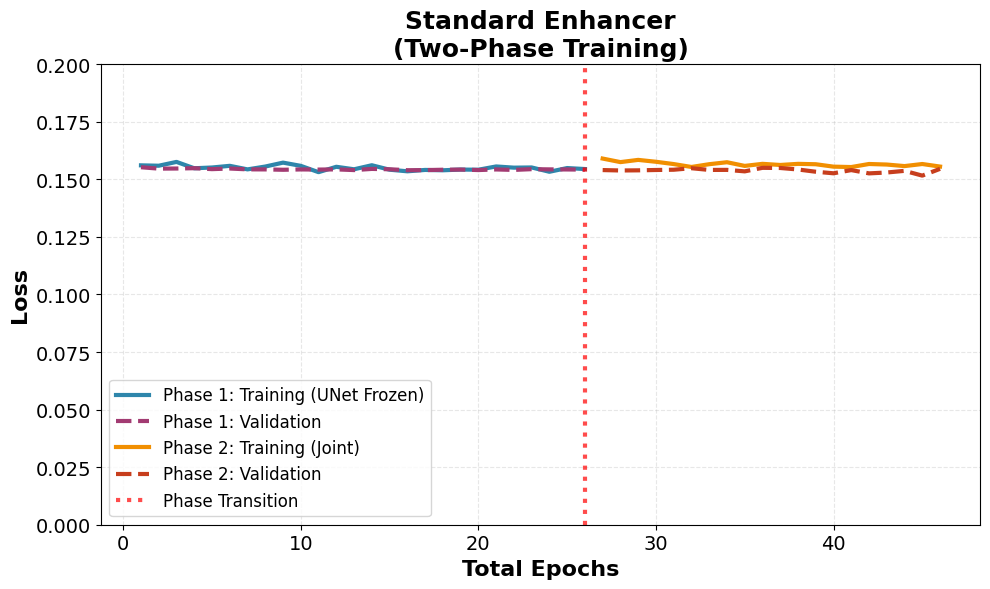

Standard Enhancer:
  Phase 1: 26 epochs, Final Loss: 0.154448
  Phase 2: 20 epochs, Final Loss: 0.155521
  Total: 46 epochs


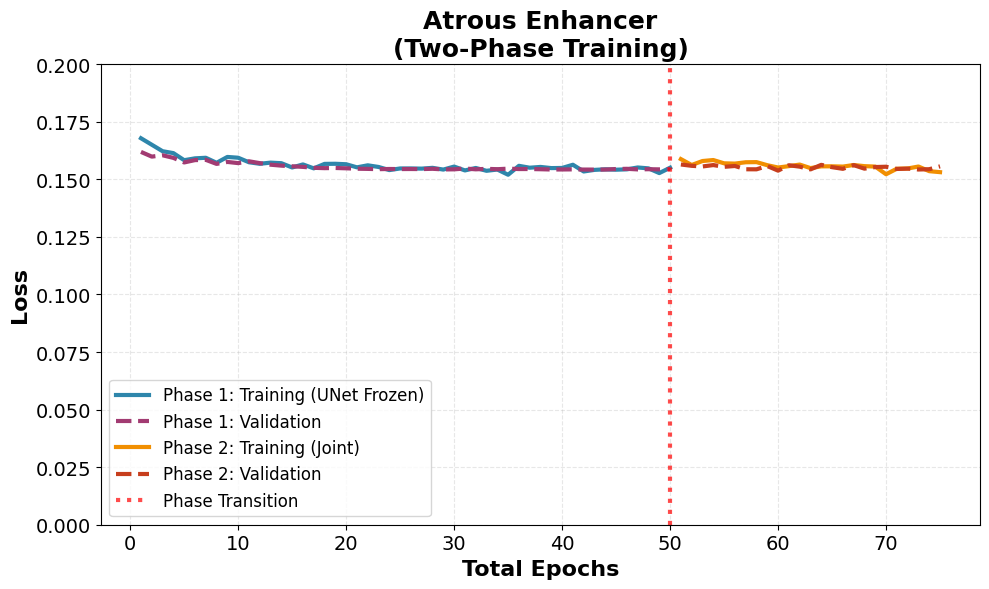


Atrous Enhancer:
  Phase 1: 50 epochs, Final Loss: 0.155013
  Phase 2: 25 epochs, Final Loss: 0.153091
  Total: 75 epochs


In [42]:
# Standard Enhancer - Combined Phases
phase1_epochs = len(enhancer_p1['train_loss'])
total_epochs_std = phase1_epochs + len(enhancer_p2['train_loss'])

# Create epoch ranges for each phase
phase1_range = list(range(1, phase1_epochs + 1))
phase2_range = list(range(phase1_epochs + 1, total_epochs_std + 1))

# Create separate figure for Standard Enhancer
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 6))

# Phase 1 data
ax1.plot(phase1_range, enhancer_p1['train_loss'], linewidth=3, color='#2E86AB', 
         label='Phase 1: Training (UNet Frozen)')
if 'val_loss' in enhancer_p1:
    ax1.plot(phase1_range, enhancer_p1['val_loss'], linewidth=3, linestyle='--', 
             color='#A23B72', label='Phase 1: Validation')

# Phase 2 data
ax1.plot(phase2_range, enhancer_p2['train_loss'], linewidth=3, color='#F18F01', 
         label='Phase 2: Training (Joint)')
if 'val_loss' in enhancer_p2:
    ax1.plot(phase2_range, enhancer_p2['val_loss'], linewidth=3, linestyle='--', 
             color='#C73E1D', label='Phase 2: Validation')

# Mark phase transition
ax1.axvline(x=phase1_epochs, color='red', linestyle=':', linewidth=3, 
            alpha=0.7, label='Phase Transition')

ax1.set_xlabel('Total Epochs', fontsize=16, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=16, fontweight='bold')
ax1.set_title('Standard Enhancer\n(Two-Phase Training)', fontsize=18, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=12, loc='lower left')
ax1.set_ylim([0, 0.20])

plt.tight_layout()
plt.savefig('../results/standard_enhancer_two_phase.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Standard Enhancer:")
print(f"  Phase 1: {phase1_epochs} epochs, Final Loss: {enhancer_p1['train_loss'][-1]:.6f}")
print(f"  Phase 2: {len(enhancer_p2['train_loss'])} epochs, Final Loss: {enhancer_p2['train_loss'][-1]:.6f}")
print(f"  Total: {total_epochs_std} epochs")

# Create separate figure for Atrous Enhancer
atrous_phase1_epochs = len(atrous_enhancer_p1['train_loss'])
total_epochs_atrous = atrous_phase1_epochs + len(atrous_enhancer_p2['train_loss'])

# Create epoch ranges for each phase
atrous_phase1_range = list(range(1, atrous_phase1_epochs + 1))
atrous_phase2_range = list(range(atrous_phase1_epochs + 1, total_epochs_atrous + 1))

fig2, ax2 = plt.subplots(1, 1, figsize=(10, 6))

# Phase 1 data
ax2.plot(atrous_phase1_range, atrous_enhancer_p1['train_loss'], linewidth=3, color='#2E86AB', 
         label='Phase 1: Training (UNet Frozen)')
if 'val_loss' in atrous_enhancer_p1:
    ax2.plot(atrous_phase1_range, atrous_enhancer_p1['val_loss'], linewidth=3, linestyle='--', 
             color='#A23B72', label='Phase 1: Validation')

# Phase 2 data
ax2.plot(atrous_phase2_range, atrous_enhancer_p2['train_loss'], linewidth=3, color='#F18F01', 
         label='Phase 2: Training (Joint)')
if 'val_loss' in atrous_enhancer_p2:
    ax2.plot(atrous_phase2_range, atrous_enhancer_p2['val_loss'], linewidth=3, linestyle='--', 
             color='#C73E1D', label='Phase 2: Validation')

# Mark phase transition
ax2.axvline(x=atrous_phase1_epochs, color='red', linestyle=':', linewidth=3, 
            alpha=0.7, label='Phase Transition')

ax2.set_xlabel('Total Epochs', fontsize=16, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=16, fontweight='bold')
ax2.set_title('Atrous Enhancer\n(Two-Phase Training)', fontsize=18, fontweight='bold')
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=12, loc='lower left')
ax2.set_ylim([0, 0.20])

plt.tight_layout()
plt.savefig('../results/atrous_enhancer_two_phase.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nAtrous Enhancer:")
print(f"  Phase 1: {atrous_phase1_epochs} epochs, Final Loss: {atrous_enhancer_p1['train_loss'][-1]:.6f}")
print(f"  Phase 2: {len(atrous_enhancer_p2['train_loss'])} epochs, Final Loss: {atrous_enhancer_p2['train_loss'][-1]:.6f}")
print(f"  Total: {total_epochs_atrous} epochs")

## Combined Visualization: All Models Together

This provides an overview of how all models compare in terms of training loss.

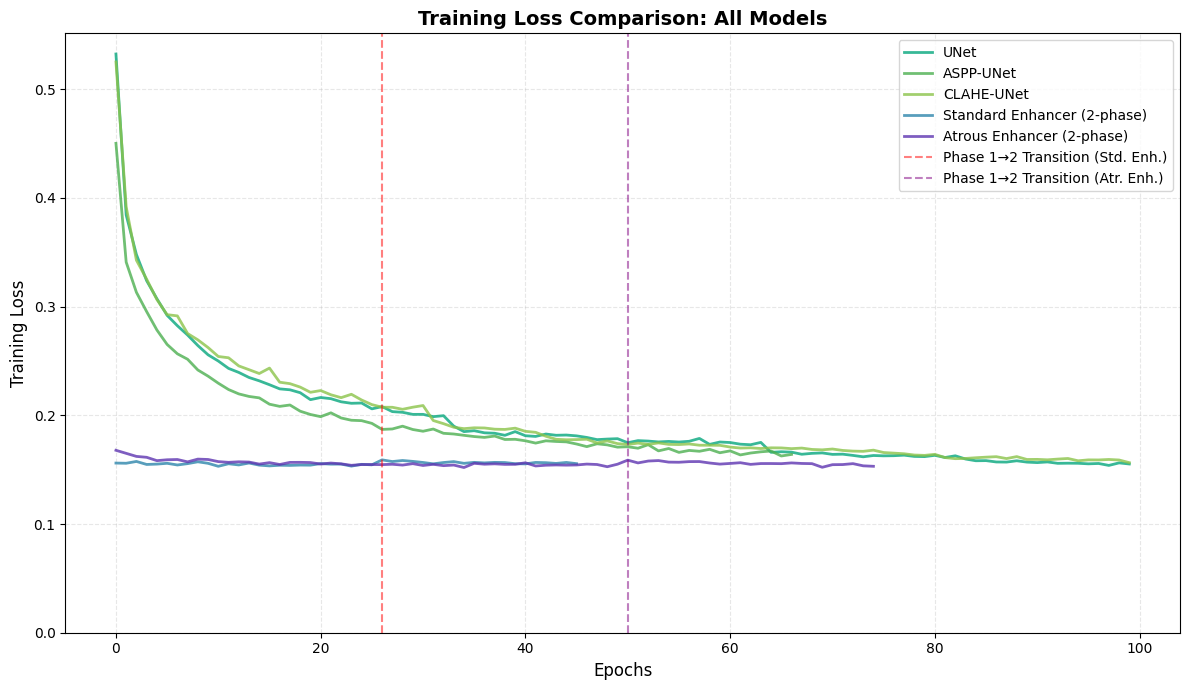

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Single-phase models
ax.plot(unet['train_loss'], linewidth=2, color='#06A77D', 
        label='UNet', alpha=0.8)
ax.plot(aspp_unet['train_loss'], linewidth=2, color='#4CAF50', 
        label='ASPP-UNet', alpha=0.8)
ax.plot(clahe_unet['train_loss'], linewidth=2, color='#8BC34A', 
        label='CLAHE-UNet', alpha=0.8)

# Two-phase models - concatenate phase 1 and phase 2
enhancer_combined = enhancer_p1['train_loss'] + enhancer_p2['train_loss']
atrous_enhancer_combined = atrous_enhancer_p1['train_loss'] + atrous_enhancer_p2['train_loss']

ax.plot(enhancer_combined, linewidth=2, color='#2E86AB', 
        label='Standard Enhancer (2-phase)', alpha=0.8)
ax.plot(atrous_enhancer_combined, linewidth=2, color='#5E35B1', 
        label='Atrous Enhancer (2-phase)', alpha=0.8)

# Mark phase transition for two-phase models
phase1_epochs = len(enhancer_p1['train_loss'])
ax.axvline(x=phase1_epochs, color='red', linestyle='--', linewidth=1.5, 
           alpha=0.5, label='Phase 1→2 Transition (Std. Enh.)')

atrous_phase1_epochs = len(atrous_enhancer_p1['train_loss'])
ax.axvline(x=atrous_phase1_epochs, color='purple', linestyle='--', linewidth=1.5, 
           alpha=0.5, label='Phase 1→2 Transition (Atr. Enh.)')

ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Training Loss Comparison: All Models', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../results/all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary Statistics

In [44]:
import pandas as pd

# Create summary dataframe
summary_data = {
    'Model': [
        'Standard Enhancer (P1)',
        'Standard Enhancer (P2)',
        'Standard Enhancer (Total)',
        'Atrous Enhancer (P1)',
        'Atrous Enhancer (P2)',
        'Atrous Enhancer (Total)',
        'UNet',
        'ASPP-UNet',
        'CLAHE-UNet'
    ],
    'Epochs': [
        len(enhancer_p1['train_loss']),
        len(enhancer_p2['train_loss']),
        len(enhancer_p1['train_loss']) + len(enhancer_p2['train_loss']),
        len(atrous_enhancer_p1['train_loss']),
        len(atrous_enhancer_p2['train_loss']),
        len(atrous_enhancer_p1['train_loss']) + len(atrous_enhancer_p2['train_loss']),
        len(unet['train_loss']),
        len(aspp_unet['train_loss']),
        len(clahe_unet['train_loss'])
    ],
    'Initial Loss': [
        enhancer_p1['train_loss'][0],
        enhancer_p2['train_loss'][0],
        enhancer_p1['train_loss'][0],
        atrous_enhancer_p1['train_loss'][0],
        atrous_enhancer_p2['train_loss'][0],
        atrous_enhancer_p1['train_loss'][0],
        unet['train_loss'][0],
        aspp_unet['train_loss'][0],
        clahe_unet['train_loss'][0]
    ],
    'Final Loss': [
        enhancer_p1['train_loss'][-1],
        enhancer_p2['train_loss'][-1],
        enhancer_p2['train_loss'][-1],
        atrous_enhancer_p1['train_loss'][-1],
        atrous_enhancer_p2['train_loss'][-1],
        atrous_enhancer_p2['train_loss'][-1],
        unet['train_loss'][-1],
        aspp_unet['train_loss'][-1],
        clahe_unet['train_loss'][-1]
    ],
    'Min Loss': [
        min(enhancer_p1['train_loss']),
        min(enhancer_p2['train_loss']),
        min(enhancer_combined),
        min(atrous_enhancer_p1['train_loss']),
        min(atrous_enhancer_p2['train_loss']),
        min(atrous_enhancer_combined),
        min(unet['train_loss']),
        min(aspp_unet['train_loss']),
        min(clahe_unet['train_loss'])
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Loss Reduction'] = summary_df['Initial Loss'] - summary_df['Final Loss']
summary_df['Loss Reduction %'] = (summary_df['Loss Reduction'] / summary_df['Initial Loss'] * 100).round(2)

print("\n" + "="*80)
print("TRAINING SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


TRAINING SUMMARY
                    Model  Epochs  Initial Loss  Final Loss  Min Loss  Loss Reduction  Loss Reduction %
   Standard Enhancer (P1)      26      0.156053    0.154448  0.153083        0.001606              1.03
   Standard Enhancer (P2)      20      0.158997    0.155521  0.155310        0.003475              2.19
Standard Enhancer (Total)      46      0.156053    0.155521  0.153083        0.000532              0.34
     Atrous Enhancer (P1)      50      0.167816    0.155013  0.151966        0.012802              7.63
     Atrous Enhancer (P2)      25      0.158756    0.153091  0.152190        0.005666              3.57
  Atrous Enhancer (Total)      75      0.167816    0.153091  0.151966        0.014725              8.77
                     UNet     100      0.532334    0.155209  0.153903        0.377125             70.84
                ASPP-UNet      67      0.450152    0.164017  0.162573        0.286136             63.56
               CLAHE-UNet     100      0.52500

## Convergence Analysis for Paper

Let's analyze convergence patterns for the paper section.

In [45]:
# Convergence Analysis
print("=" * 80)
print("CONVERGENCE ANALYSIS")
print("=" * 80)

# Single-phase models
models = {
    'Standard UNet': unet,
    'ASPP-UNet': aspp_unet,
    'CLAHE-UNet': clahe_unet
}

for name, history in models.items():
    val_losses = history['val_loss']
    best_val_loss = min(val_losses)
    best_epoch = val_losses.index(best_val_loss) + 1
    final_val_loss = val_losses[-1]
    total_epochs = len(val_losses)
    
    # Calculate when model reached within 1% of best
    threshold = best_val_loss * 1.01
    convergence_epoch = next((i+1 for i, loss in enumerate(val_losses) if loss <= threshold), total_epochs)
    
    print(f"\n{name}:")
    print(f"  Total epochs: {total_epochs}")
    print(f"  Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")
    print(f"  Final val loss: {final_val_loss:.4f}")
    print(f"  Converged (within 1% of best) at epoch: {convergence_epoch}")
    print(f"  Training efficiency: {convergence_epoch}/{total_epochs} epochs to convergence")
    
    # Check stability in last 15 epochs
    if total_epochs >= 15:
        last_15 = val_losses[-15:]
        variance = np.var(last_15)
        is_stable = variance < 0.0001
        print(f"  Last 15 epochs variance: {variance:.6f} ({'stable' if is_stable else 'unstable'})")

# Two-phase models - analyze each phase
print("\n" + "=" * 80)
print("TWO-PHASE MODELS")
print("=" * 80)

enhancer_models = {
    'Standard Enhancer': {
        'phase1': enhancer_p1,
        'phase2': enhancer_p2
    },
    'Atrous Enhancer': {
        'phase1': atrous_enhancer_p1,
        'phase2': atrous_enhancer_p2
    }
}

for name, phases in enhancer_models.items():
    print(f"\n{name}:")
    
    # Phase 1
    p1_losses = phases['phase1']['train_loss']
    p1_epochs = len(p1_losses)
    p1_initial = p1_losses[0]
    p1_final = p1_losses[-1]
    p1_reduction = ((p1_initial - p1_final) / p1_initial * 100)
    
    print(f"  Phase 1 ({p1_epochs} epochs):")
    print(f"    Initial loss: {p1_initial:.4f}")
    print(f"    Final loss: {p1_final:.4f}")
    print(f"    Reduction: {p1_reduction:.2f}%")
    
    # Phase 2
    p2_losses = phases['phase2']['train_loss']
    p2_epochs = len(p2_losses)
    p2_initial = p2_losses[0]
    p2_final = p2_losses[-1]
    p2_reduction = ((p2_initial - p2_final) / p2_initial * 100)
    
    print(f"  Phase 2 ({p2_epochs} epochs):")
    print(f"    Initial loss: {p2_initial:.4f}")
    print(f"    Final loss: {p2_final:.4f}")
    print(f"    Reduction: {p2_reduction:.2f}%")
    print(f"  Total epochs: {p1_epochs + p2_epochs}")

print("\n" + "=" * 80)

CONVERGENCE ANALYSIS

Standard UNet:
  Total epochs: 100
  Best val loss: 0.1542 at epoch 100
  Final val loss: 0.1542
  Converged (within 1% of best) at epoch: 87
  Training efficiency: 87/100 epochs to convergence
  Last 15 epochs variance: 0.000002 (stable)

ASPP-UNet:
  Total epochs: 67
  Best val loss: 0.1528 at epoch 52
  Final val loss: 0.1589
  Converged (within 1% of best) at epoch: 52
  Training efficiency: 52/67 epochs to convergence
  Last 15 epochs variance: 0.000003 (stable)

CLAHE-UNet:
  Total epochs: 100
  Best val loss: 0.1614 at epoch 95
  Final val loss: 0.1615
  Converged (within 1% of best) at epoch: 79
  Training efficiency: 79/100 epochs to convergence
  Last 15 epochs variance: 0.000001 (stable)

TWO-PHASE MODELS

Standard Enhancer:
  Phase 1 (26 epochs):
    Initial loss: 0.1561
    Final loss: 0.1544
    Reduction: 1.03%
  Phase 2 (20 epochs):
    Initial loss: 0.1590
    Final loss: 0.1555
    Reduction: 2.19%
  Total epochs: 46

Atrous Enhancer:
  Phase 1 (

In [46]:
def compute_convergence_epoch(val_losses, threshold_percent=1.0):
    """Find the epoch when model reached within threshold% of best validation loss."""
    best_val_loss = min(val_losses)
    threshold = best_val_loss * (1 + threshold_percent / 100)
    
    for i, loss in enumerate(val_losses):
        if loss <= threshold:
            return i + 1  # 1-indexed
    
    return len(val_losses)


def compute_unet_metrics(history):
    """Compute metrics for single-phase UNet models."""
    val_losses = history['val_loss']
    
    best_val_loss = min(val_losses)
    best_epoch = val_losses.index(best_val_loss) + 1
    final_val_loss = val_losses[-1]
    total_epochs = len(val_losses)
    convergence_epoch = compute_convergence_epoch(val_losses)
    
    metrics = {
        "total_epochs": total_epochs,
        "best_val_loss": round(best_val_loss, 4),
        "best_epoch": best_epoch,
        "final_val_loss": round(final_val_loss, 4),
        "convergence_epoch": convergence_epoch
    }
    
    # Calculate variance for last 15 epochs if applicable
    if total_epochs >= 15:
        last_15 = val_losses[-15:]
        variance = float(np.var(last_15))
        metrics["last_15_variance"] = variance
    
    # Calculate overfitting increase if final != best
    if final_val_loss > best_val_loss:
        increase_percent = ((final_val_loss - best_val_loss) / best_val_loss) * 100
        metrics["overfitting_increase_percent"] = round(increase_percent, 2)
    
    return metrics


def compute_enhancer_metrics(phase1_history, phase2_history):
    """Compute metrics for two-phase enhancer models."""
    p1_losses = phase1_history['train_loss']
    p2_losses = phase2_history['train_loss']
    
    phase1_epochs = len(p1_losses)
    phase2_epochs = len(p2_losses)
    
    p1_initial = p1_losses[0]
    p1_final = p1_losses[-1]
    p1_reduction_percent = ((p1_initial - p1_final) / p1_initial) * 100
    
    p2_initial = p2_losses[0]
    p2_final = p2_losses[-1]
    p2_reduction_percent = ((p2_initial - p2_final) / p2_initial) * 100
    
    return {
        "phase1_epochs": phase1_epochs,
        "phase2_epochs": phase2_epochs,
        "total_epochs": phase1_epochs + phase2_epochs,
        "phase1_initial_loss": round(p1_initial, 4),
        "phase1_final_loss": round(p1_final, 4),
        "phase1_reduction_percent": round(p1_reduction_percent, 2),
        "phase2_initial_loss": round(p2_initial, 4),
        "phase2_final_loss": round(p2_final, 4),
        "phase2_reduction_percent": round(p2_reduction_percent, 2)
    }


# Compute metrics for all models
convergence_metrics = {
    "unet": compute_unet_metrics(unet),
    "aspp_unet": compute_unet_metrics(aspp_unet),
    "clahe_unet": compute_unet_metrics(clahe_unet),
    "std_enhancer": compute_enhancer_metrics(enhancer_p1, enhancer_p2),
    "atrous_enhancer": compute_enhancer_metrics(atrous_enhancer_p1, atrous_enhancer_p2)
}

# Save to JSON file for use in Typst paper
output_path = results_dir / 'convergence_metrics.json'
with open(output_path, 'w') as f:
    json.dump(convergence_metrics, f, indent=2)

print(f"Convergence metrics saved to {output_path}")
print("\n" + "="*80)
print("CONVERGENCE METRICS SUMMARY")
print("="*80)
print(json.dumps(convergence_metrics, indent=2))

Convergence metrics saved to ../results/convergence_metrics.json

CONVERGENCE METRICS SUMMARY
{
  "unet": {
    "total_epochs": 100,
    "best_val_loss": 0.1542,
    "best_epoch": 100,
    "final_val_loss": 0.1542,
    "convergence_epoch": 87,
    "last_15_variance": 1.5047356495790993e-06
  },
  "aspp_unet": {
    "total_epochs": 67,
    "best_val_loss": 0.1528,
    "best_epoch": 52,
    "final_val_loss": 0.1589,
    "convergence_epoch": 52,
    "last_15_variance": 3.2387814704199735e-06,
    "overfitting_increase_percent": 3.98
  },
  "clahe_unet": {
    "total_epochs": 100,
    "best_val_loss": 0.1614,
    "best_epoch": 95,
    "final_val_loss": 0.1615,
    "convergence_epoch": 79,
    "last_15_variance": 1.3365194925215426e-06,
    "overfitting_increase_percent": 0.05
  },
  "std_enhancer": {
    "phase1_epochs": 26,
    "phase2_epochs": 20,
    "total_epochs": 46,
    "phase1_initial_loss": 0.1561,
    "phase1_final_loss": 0.1544,
    "phase1_reduction_percent": 1.03,
    "phase2_

## Generate Convergence Metrics for Paper

This section computes convergence metrics and saves them to a JSON file that can be dynamically imported into the Typst paper.